# GAN Evaluation — All Runs

Evaluates all trained runs and saves plots to each run's artifact folder.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from scipy import stats

REPO_ROOT = Path("..")
sys.path.insert(0, str(REPO_ROOT))

from notebooks.TCN_marketgan_full_Lucas import (
    MarketGANConfig,
    prepare_marketgan_data,
    MarketGANSequenceDataset,
    MarketGenerator,
    MarketCritic,
    MarketGANTrainer,
)

ARTIFACT_ROOT = REPO_ROOT / "artifacts" / "marketgan_tcn"
N_SAMPLES     = 50
N_BOOTSTRAP   = 500

EQUITY_COLS    = ["aapl", "amzn", "jnj", "jpm", "msft", "nflx", "nvda", "tsla", "v", "xom"]
BOND_COLS      = ["agg", "bnd", "emb", "hyg", "ief", "lqd", "mub", "shy", "tip", "tlt"]
COMMODITY_COLS = ["coffee", "copper", "corn", "crude_oil", "gold", "natural_gas", "platinum", "silver", "soybeans", "wheat"]

In [2]:
# ── Run configurations ────────────────────────────────────────────────────────
# Each entry fully describes how to reconstruct the data pipeline used at training time.

config_default = MarketGANConfig(target_horizon=252 * 4)

returns_raw = pd.read_csv(config_default.returns_path, parse_dates=["Date"]).set_index("Date")

factor_3raw = pd.DataFrame({
    "equity_factor":    returns_raw[EQUITY_COLS].mean(axis=1),
    "bond_factor":      returns_raw[BOND_COLS].mean(axis=1),
    "commodity_factor": returns_raw[COMMODITY_COLS].mean(axis=1),
})
factor_3norm = (factor_3raw - factor_3raw.mean()) / factor_3raw.std()

RUN_CONFIGS = [
    {
        "run_name":         "marketgan_proxy_factor_run",
        "label":            "Run 1 — Proxy Factor (25 epochs)",
        "factor_frame":     None,           # single proxy factor built automatically
        "normalize_factors": False,
        "cholesky_L":       None,
    },
    {
        "run_name":         "marketgan_run2_bs32_cs3_3factors",
        "label":            "Run 2 — 3 Factors (100 epochs)",
        "factor_frame":     factor_3raw,    # raw 3-factor, not normalized
        "normalize_factors": False,
        "cholesky_L":       None,
    },
    {
        "run_name":         "marketgan_run3_volreg_normfactors",
        "label":            "Run 3 — 3 Factors + Vol Reg + Normalized (100 epochs)",
        "factor_frame":     factor_3norm,   # z-score normalized factors
        "normalize_factors": False,         # already done above
        "cholesky_L":       None,
    },
]

for rc in RUN_CONFIGS:
    cp = ARTIFACT_ROOT / rc["run_name"] / "checkpoints" / "best.pt"
    print(f"{rc['label']:55s}  checkpoint={'✓' if cp.exists() else '✗ MISSING'}")

Run 1 — Proxy Factor (25 epochs)                         checkpoint=✓
Run 2 — 3 Factors (100 epochs)                           checkpoint=✓
Run 3 — 3 Factors + Vol Reg + Normalized (100 epochs)    checkpoint=✓


In [3]:
def evaluate_run(rc, artifact_root, n_samples=50, n_bootstrap=500):
    run_name     = rc["run_name"]
    label        = rc["label"]
    out_dir      = artifact_root / run_name
    checkpoint   = artifact_root / run_name / "checkpoints" / "best.pt"

    if not checkpoint.exists():
        print(f"Skipping {run_name} — best.pt not found")
        return None

    config = MarketGANConfig(target_horizon=252 * 4)
    prepared_data = prepare_marketgan_data(config=config, factor_frame=rc["factor_frame"])
    dataset = MarketGANSequenceDataset(prepared_data, sequence_length=config.total_sequence_length)

    generator = MarketGenerator(prepared_data.dimensions, config, cholesky_L=rc["cholesky_L"]).to(config.device)
    ckpt = torch.load(checkpoint, map_location=config.device)
    generator.load_state_dict(ckpt["generator_state_dict"])
    generator.eval()

    print(f"\n{'='*60}")
    print(f"{label}  (best epoch: {ckpt['epoch']})")
    print(f"  Assets: {prepared_data.dimensions.num_assets}  "
          f"Factors: {prepared_data.dimensions.num_factors}  "
          f"Covariates: {prepared_data.dimensions.num_covariates}")

    # ── Generate N synthetic windows ──────────────────────────────
    indices = np.linspace(0, len(dataset) - 1, n_samples, dtype=int)
    generated_list, real_list = [], []

    with torch.no_grad():
        for idx in indices:
            sample = dataset[int(idx)]
            batch  = {k: v.unsqueeze(0).to(config.device) for k, v in sample.items()}
            out    = generator(
                covariates=batch["covariates"],
                factor_returns=batch["factors"],
                alpha_hat=batch["alpha_hat"],
                beta_hat=batch["beta_hat"],
                sigma_hat=batch["sigma_hat"],
                trim_output=True,
            )
            generated_list.append(out["generated_returns_trimmed"][0].cpu().numpy())
            real_list.append(batch["real_returns"][0, config.warmup_period:, :].cpu().numpy())

    gen_df  = pd.DataFrame(np.concatenate(generated_list, axis=0), columns=prepared_data.asset_columns)
    real_df = pd.DataFrame(np.concatenate(real_list,      axis=0), columns=prepared_data.asset_columns)

    gen_df.to_csv(out_dir / "generated_returns.csv", index=False)

    # ── Plot 1: Center Mass ────────────────────────────────────────
    s_real = pd.DataFrame({"mean": real_df.mean(), "std": real_df.std(), "skew": real_df.skew(), "kurtosis": real_df.kurtosis()})
    s_gen  = pd.DataFrame({"mean": gen_df.mean(),  "std": gen_df.std(),  "skew": gen_df.skew(),  "kurtosis": gen_df.kurtosis()})

    fig, axes = plt.subplots(2, 2, figsize=(14, 8))
    for ax, m, t in zip(axes.flat,
                        ["mean", "std", "skew", "kurtosis"],
                        ["Mean return", "Volatility (std)", "Skewness", "Excess Kurtosis"]):
        ax.scatter(s_real[m], s_gen[m], alpha=0.7, s=40)
        lo = min(s_real[m].min(), s_gen[m].min())
        hi = max(s_real[m].max(), s_gen[m].max())
        ax.plot([lo, hi], [lo, hi], "r--", linewidth=1, label="perfect")
        ax.set_xlabel("Real"); ax.set_ylabel("Generated"); ax.set_title(t)
        ax.legend(); ax.grid(alpha=0.3)
    plt.suptitle(f"{label} — Center Mass", fontsize=13)
    plt.tight_layout()
    plt.savefig(out_dir / "eval_center_mass.png", dpi=150)
    plt.show()

    # ── Plot 2: Left Tail Exceedance ───────────────────────────────
    thresholds = np.linspace(-0.10, -0.005, 60)
    flat_real  = real_df.values.flatten()
    flat_gen   = gen_df.values.flatten()
    real_exc   = np.array([(flat_real < t).mean() for t in thresholds])
    gen_exc    = np.array([(flat_gen  < t).mean() for t in thresholds])
    boot_curves = np.array([
        [(np.random.choice(flat_real, size=len(flat_real), replace=True) < t).mean() for t in thresholds]
        for _ in range(n_bootstrap)
    ])

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(thresholds, real_exc, "b-",  linewidth=2, label="Real")
    ax.plot(thresholds, gen_exc,  "r--", linewidth=2, label="Generated")
    ax.fill_between(thresholds,
                    np.percentile(boot_curves, 2.5,  axis=0),
                    np.percentile(boot_curves, 97.5, axis=0),
                    alpha=0.2, color="blue", label="Real 95% CI (bootstrap)")
    ax.set_xlabel("Return threshold"); ax.set_ylabel("Exceedance probability")
    ax.set_title(f"{label} — Left Tail Exceedance")
    ax.legend(); ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(out_dir / "eval_left_tail.png", dpi=150)
    plt.show()

    # ── Plot 3: Correlation Matrix ─────────────────────────────────
    corr_real = real_df.corr()
    corr_gen  = gen_df.corr()
    diff      = corr_gen - corr_real
    frob      = np.linalg.norm(diff.values, "fro")

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    for ax, mat, title in zip(axes,
                               [corr_real, corr_gen, diff],
                               ["Real", "Generated", f"Difference (Gen - Real)"]):
        vmin, vmax = (-1, 1) if title != f"Difference (Gen - Real)" else (-0.5, 0.5)
        im = ax.imshow(mat, vmin=vmin, vmax=vmax, cmap="RdBu_r")
        ax.set_title(title); ax.set_xticks([]); ax.set_yticks([])
        plt.colorbar(im, ax=ax)
    plt.suptitle(f"{label} — Correlation Matrix  (Frobenius diff: {frob:.3f})", fontsize=13)
    plt.tight_layout()
    plt.savefig(out_dir / "eval_correlation.png", dpi=150)
    plt.show()

    # ── Plot 4: Per-Asset Volatility ───────────────────────────────
    vol_real  = real_df.std()
    vol_gen   = gen_df.std()
    boot_vols = pd.DataFrame([
        real_df.iloc[np.random.choice(len(real_df), size=len(real_df), replace=True)].std()
        for _ in range(n_bootstrap)
    ])

    fig, ax = plt.subplots(figsize=(14, 5))
    x = np.arange(len(prepared_data.asset_columns))
    ax.bar(x - 0.2, vol_real, 0.35, label="Real",      color="steelblue", alpha=0.8)
    ax.bar(x + 0.2, vol_gen,  0.35, label="Generated", color="tomato",    alpha=0.8)
    ax.errorbar(x - 0.2, vol_real,
                yerr=[vol_real - boot_vols.quantile(0.025), boot_vols.quantile(0.975) - vol_real],
                fmt="none", color="black", capsize=3, linewidth=1)
    ax.set_xticks(x)
    ax.set_xticklabels(prepared_data.asset_columns, rotation=45, ha="right", fontsize=8)
    ax.set_ylabel("Daily return std")
    ax.set_title(f"{label} — Per-Asset Volatility (with 95% CI)")
    ax.legend(); ax.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.savefig(out_dir / "eval_volatility.png", dpi=150)
    plt.show()

    print(f"  Frobenius norm (corr diff): {frob:.4f}")
    print(f"  Saved → {out_dir}")
    return {"gen_df": gen_df, "real_df": real_df, "frob": frob}

/Users/amine/miniconda3/envs/gan-project/lib/python3.11/site-packages/torch/nn/utils/weight_norm.py:143: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)



Run 1 — Proxy Factor (25 epochs)  (best epoch: 0)
  Assets: 30  Factors: 1  Covariates: 8


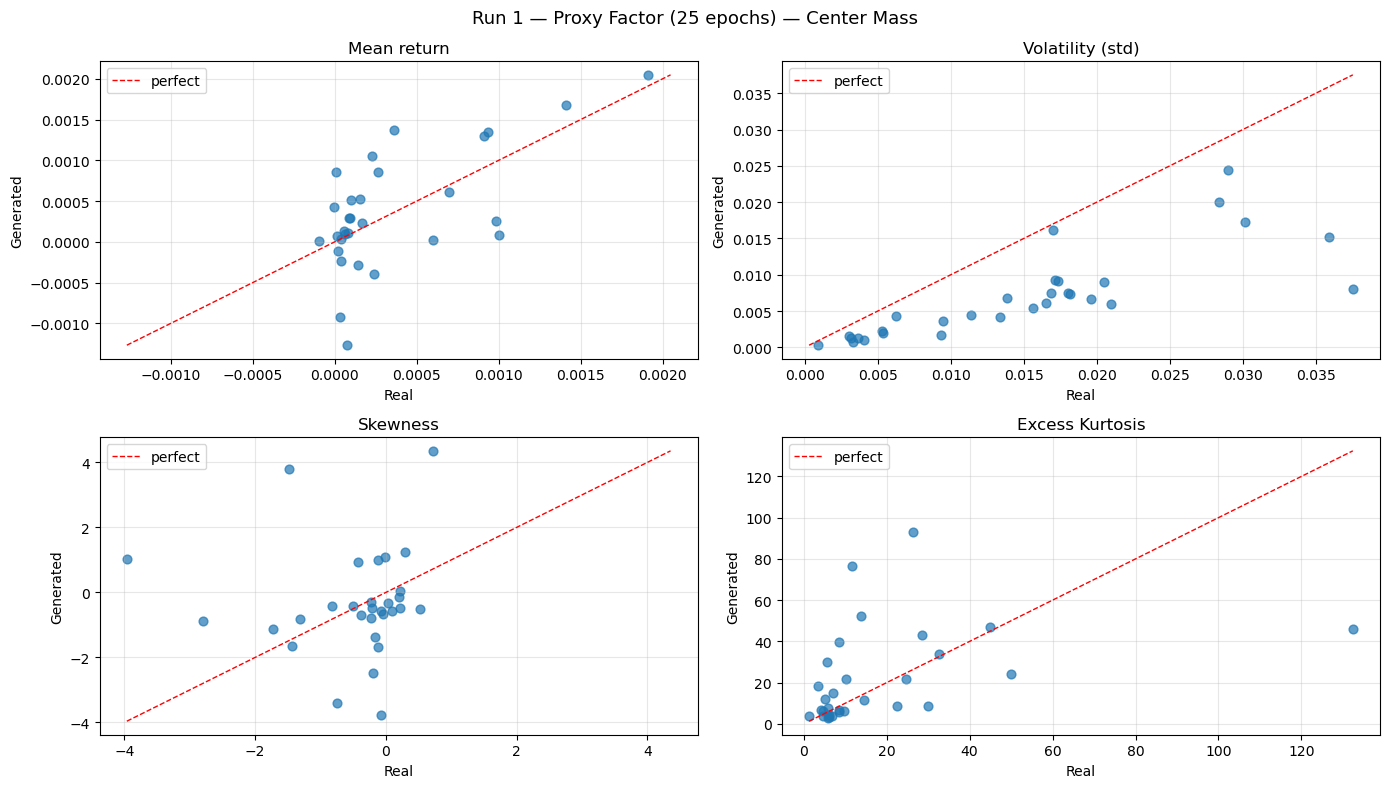

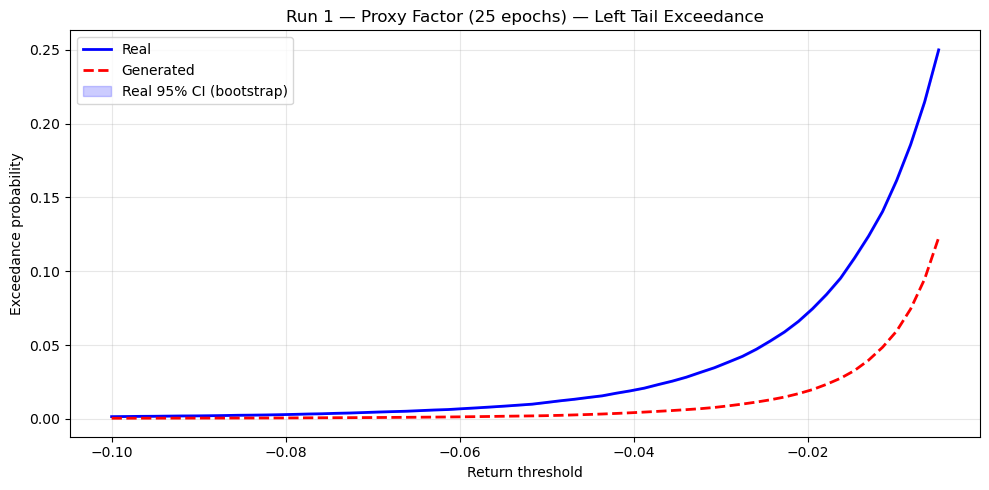

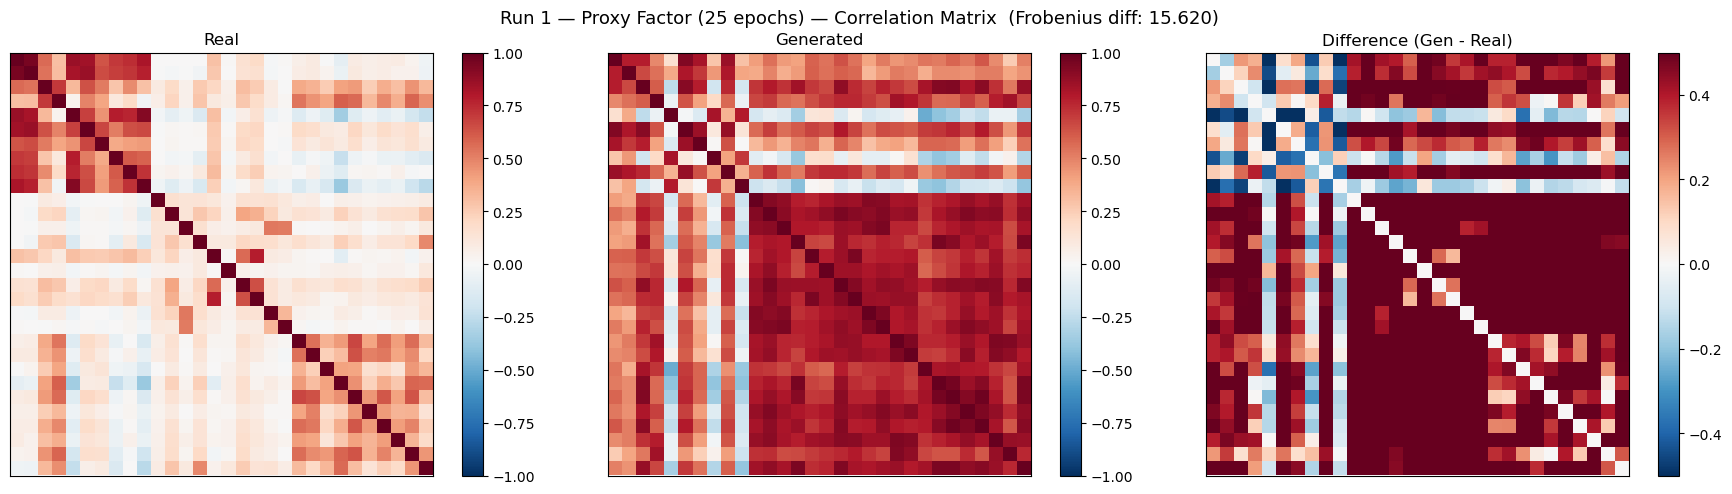

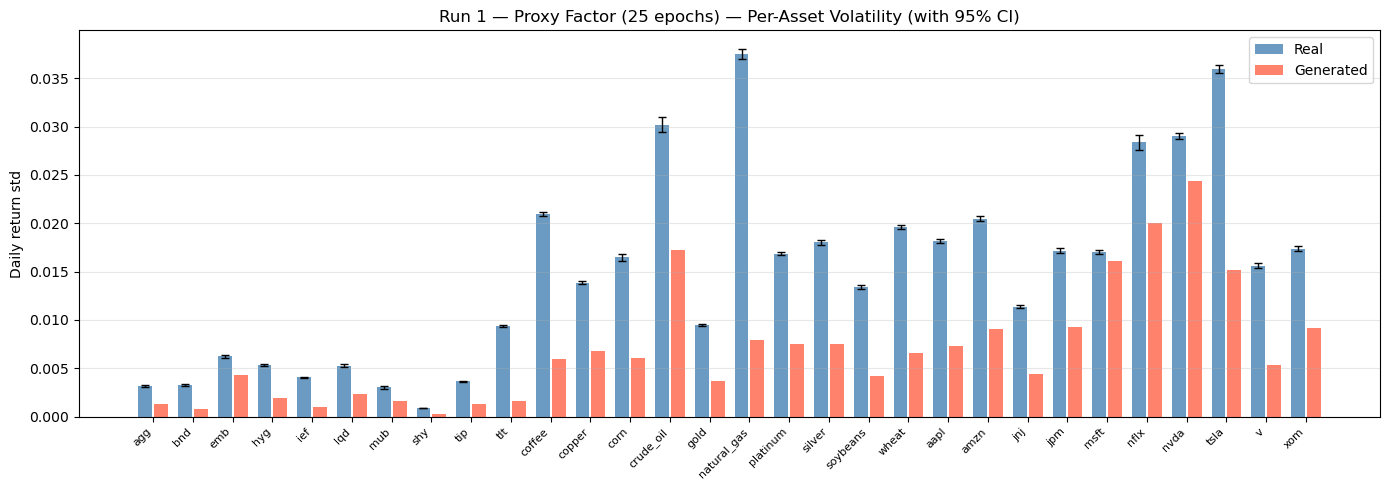

  Frobenius norm (corr diff): 15.6202
  Saved → ../artifacts/marketgan_tcn/marketgan_proxy_factor_run


/Users/amine/miniconda3/envs/gan-project/lib/python3.11/site-packages/torch/nn/utils/weight_norm.py:143: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)



Run 2 — 3 Factors (100 epochs)  (best epoch: 2)
  Assets: 30  Factors: 3  Covariates: 8


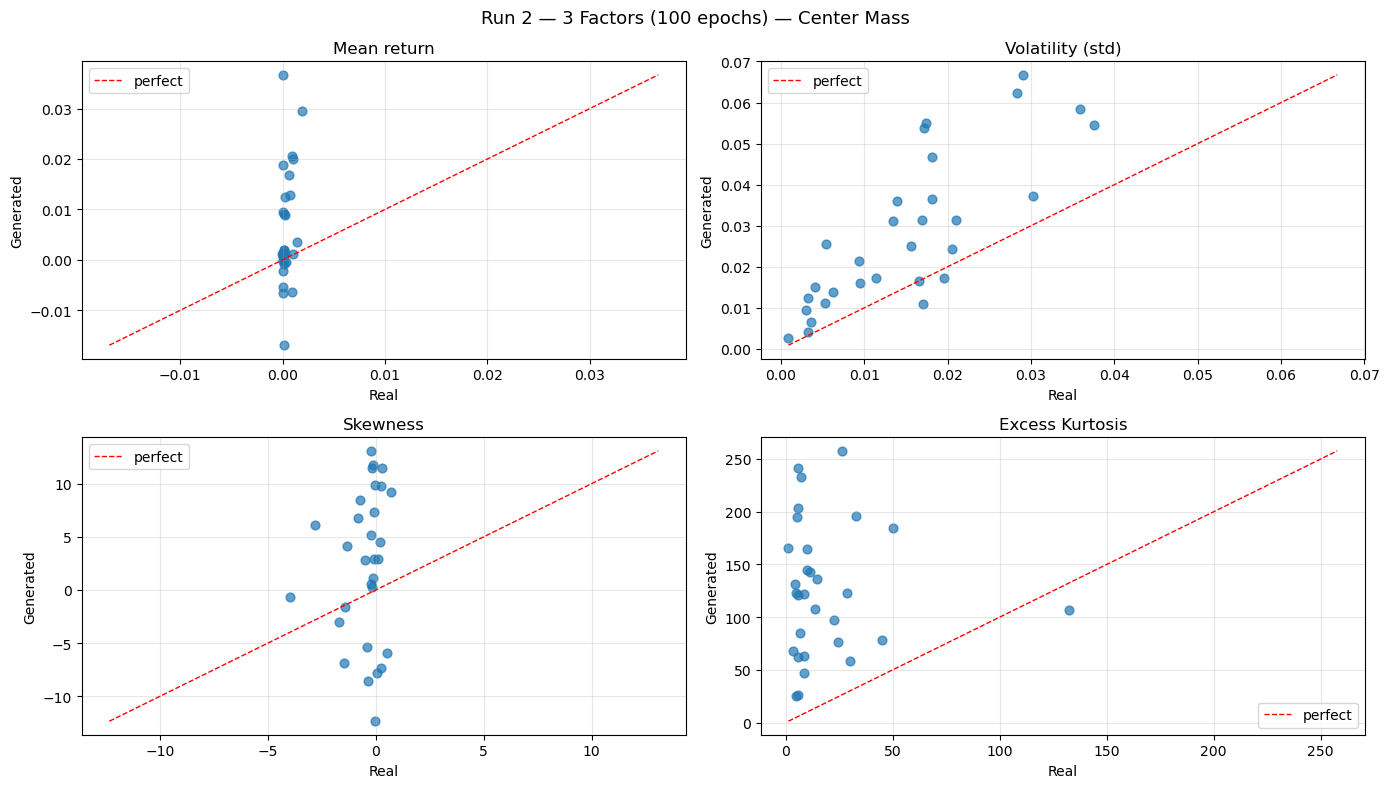

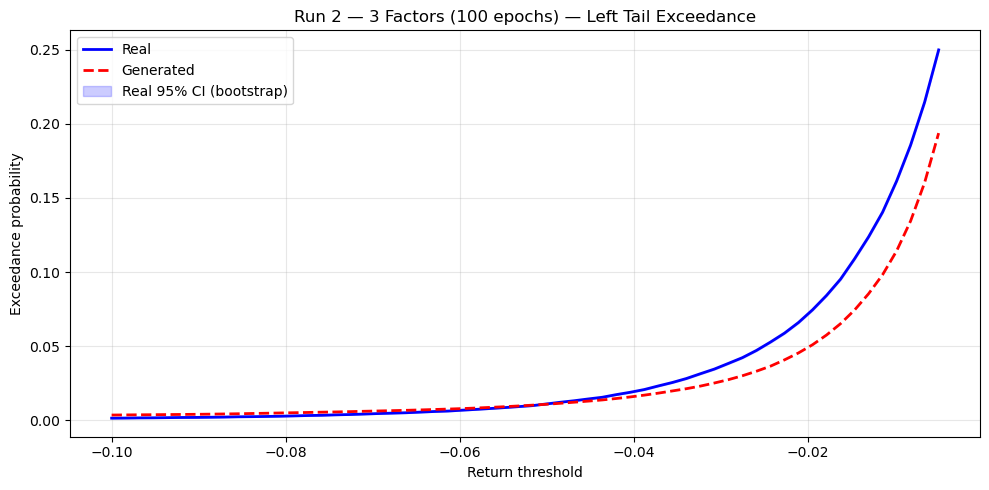

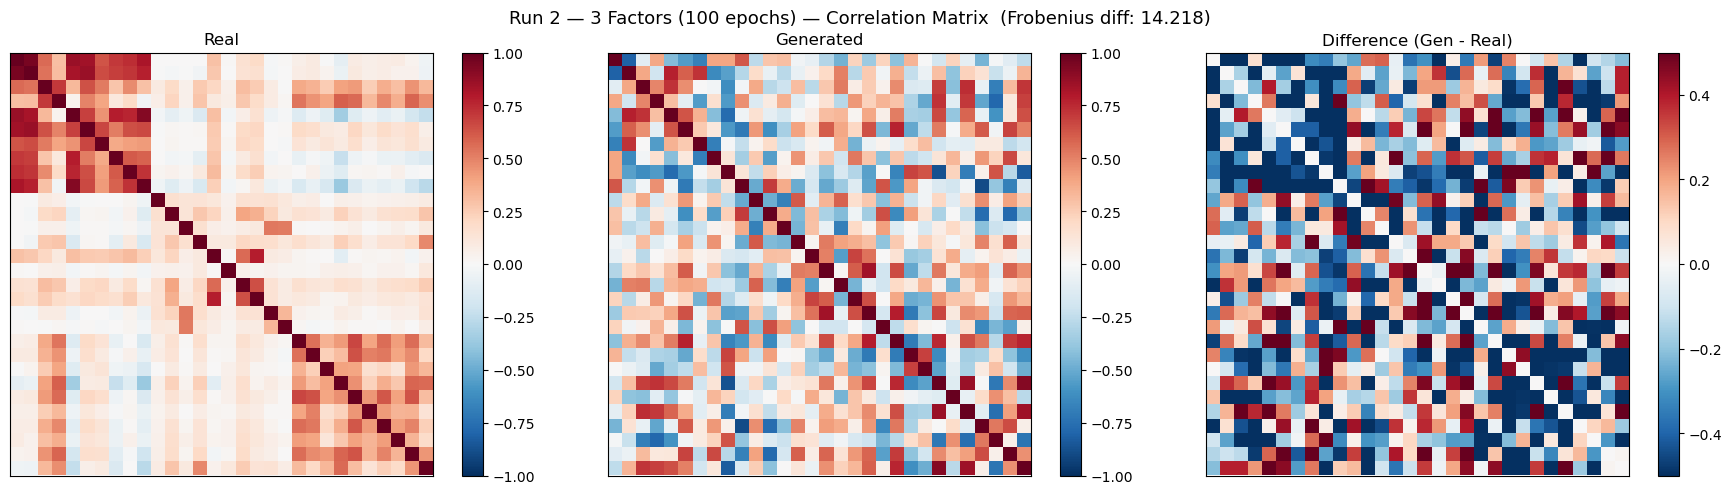

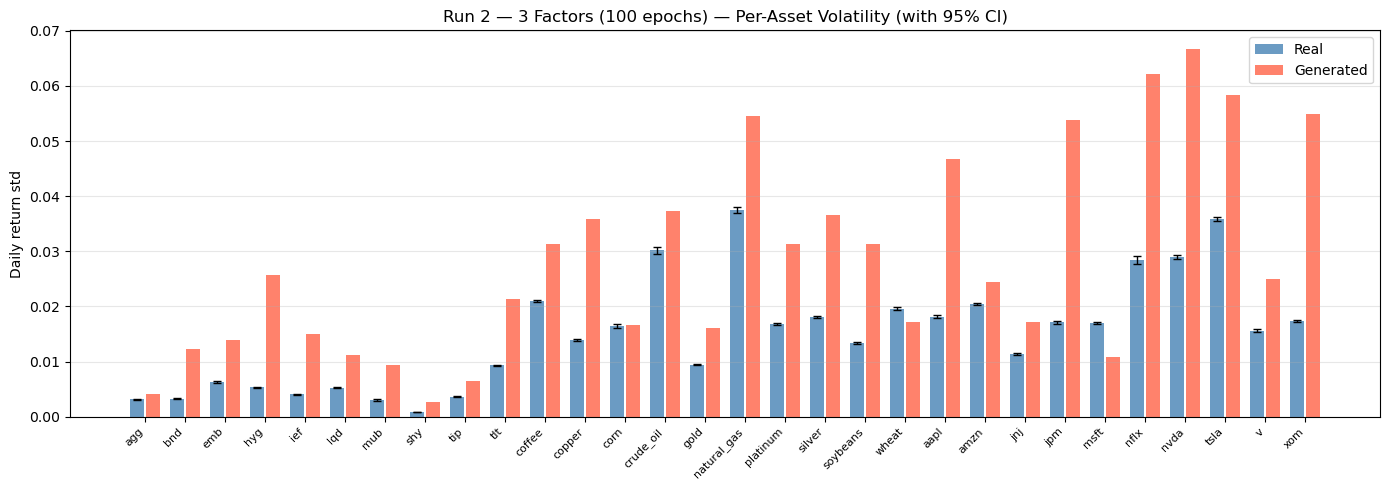

  Frobenius norm (corr diff): 14.2184
  Saved → ../artifacts/marketgan_tcn/marketgan_run2_bs32_cs3_3factors


/Users/amine/miniconda3/envs/gan-project/lib/python3.11/site-packages/torch/nn/utils/weight_norm.py:143: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)



Run 3 — 3 Factors + Vol Reg + Normalized (100 epochs)  (best epoch: 2)
  Assets: 30  Factors: 3  Covariates: 8


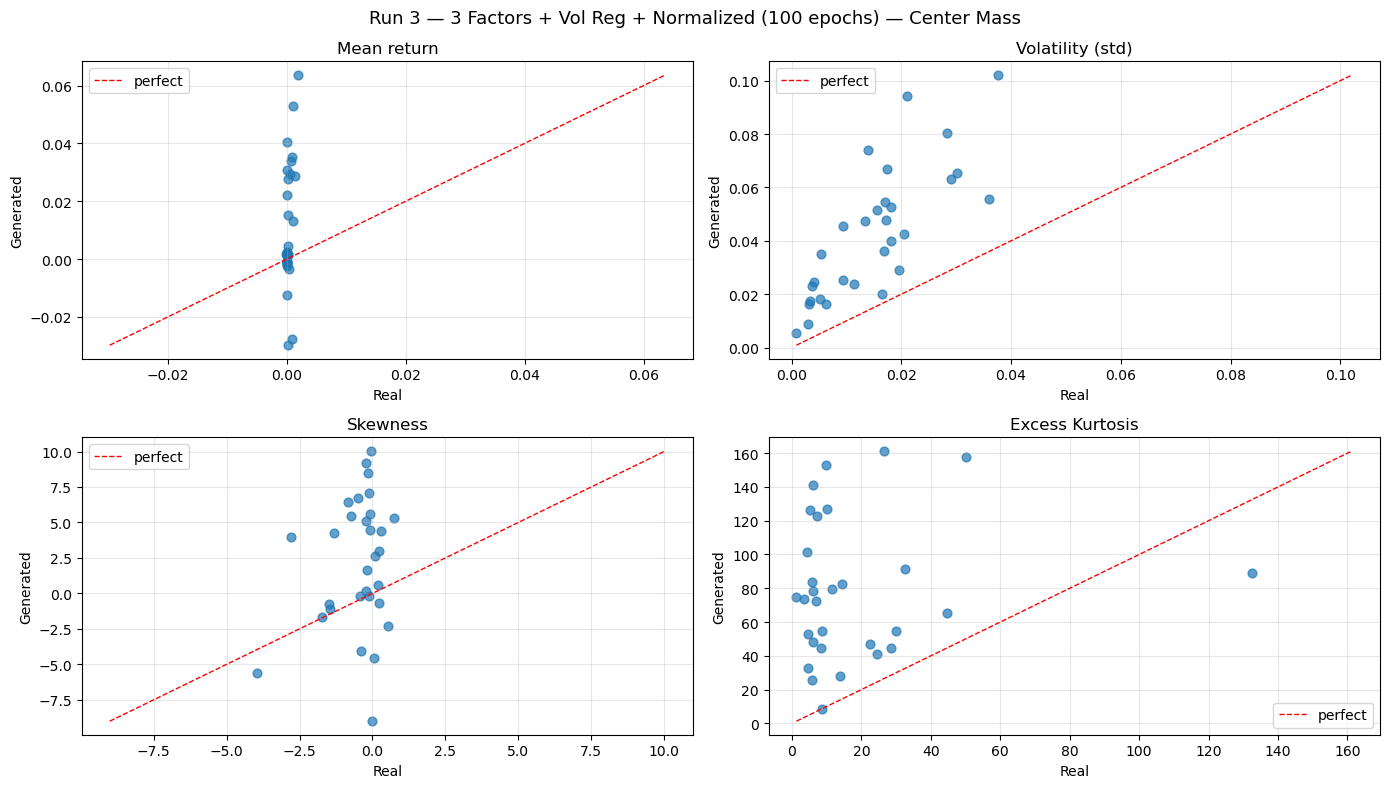

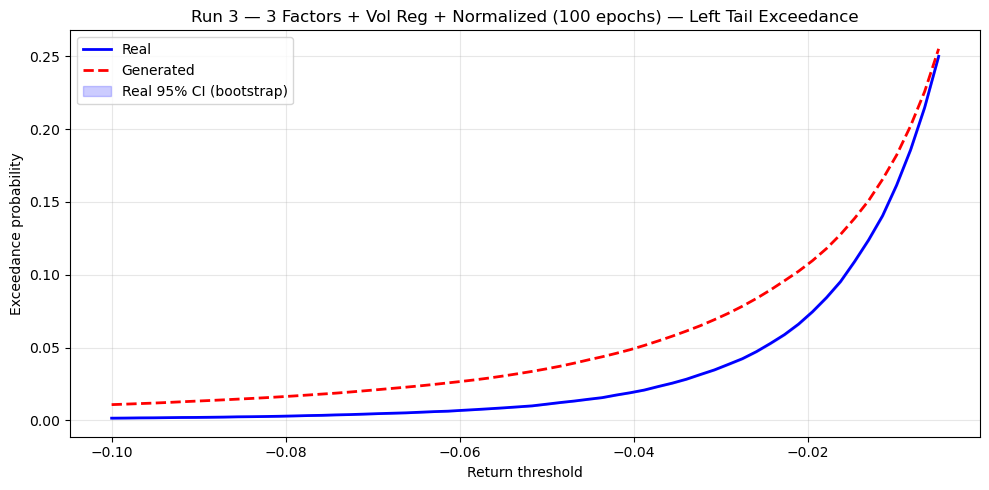

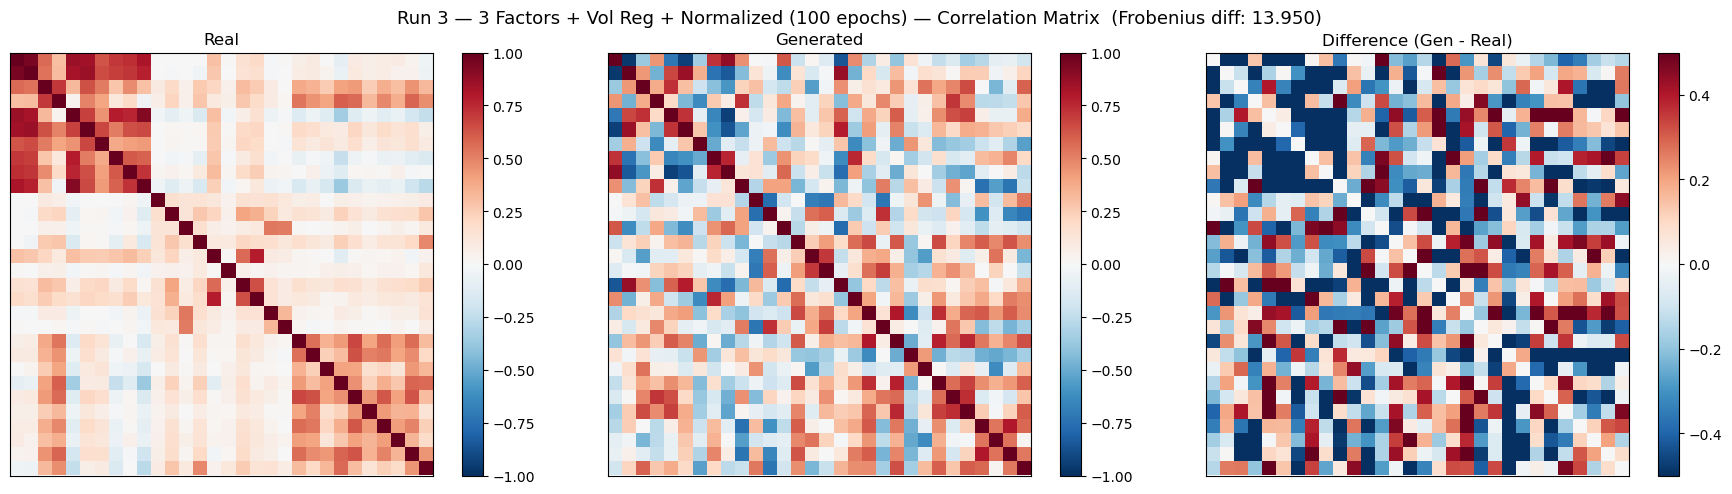

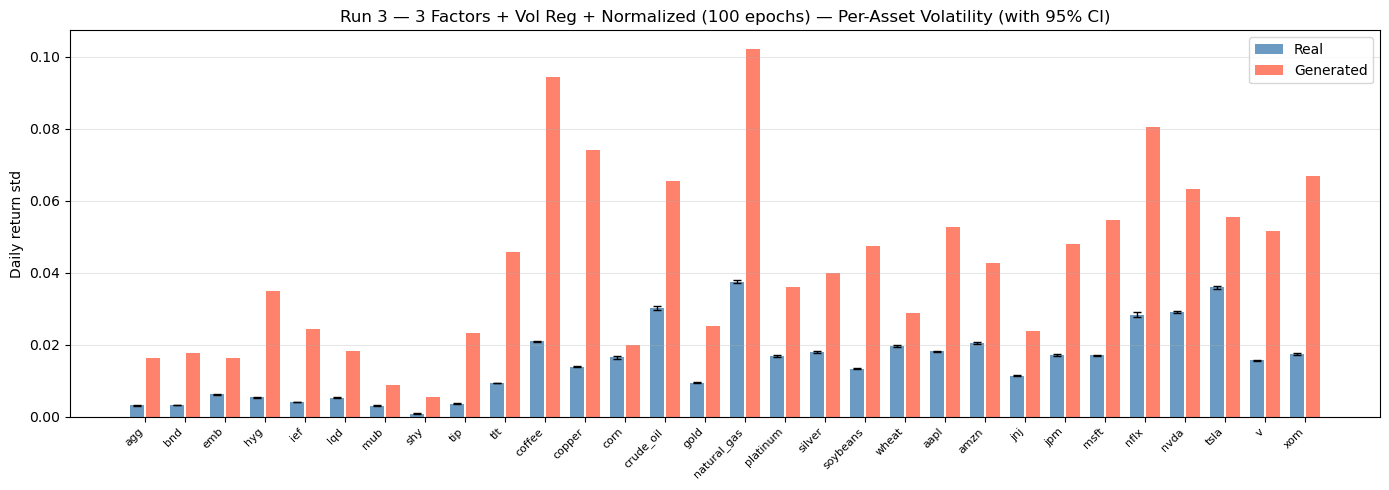

  Frobenius norm (corr diff): 13.9495
  Saved → ../artifacts/marketgan_tcn/marketgan_run3_volreg_normfactors


── Summary ──────────────────────────────────────────────────
Run                                                       Frob diff  Vol ratio (med)
-------------------------------------------------------------------------------------
Run 1 — Proxy Factor (25 epochs)                            15.6202           0.4041
Run 2 — 3 Factors (100 epochs)                              14.2184           2.0707
Run 3 — 3 Factors + Vol Reg + Normalized (100 epochs)       13.9495           2.9079


In [4]:
# ── Run evaluation on all 3 runs ──────────────────────────────────────────────
results = {}
for rc in RUN_CONFIGS:
    results[rc["run_name"]] = evaluate_run(rc, ARTIFACT_ROOT, n_samples=N_SAMPLES, n_bootstrap=N_BOOTSTRAP)

# ── Summary table ─────────────────────────────────────────────────────────────
print("\n\n── Summary ──────────────────────────────────────────────────")
print(f"{'Run':<55}  {'Frob diff':>10}  {'Vol ratio (med)':>15}")
print("-" * 85)
for rc in RUN_CONFIGS:
    r = results.get(rc["run_name"])
    if r is None:
        continue
    vol_ratio = (r["gen_df"].std() / r["real_df"].std()).median()
    print(f"{rc['label']:<55}  {r['frob']:>10.4f}  {vol_ratio:>15.4f}")